<a href="https://colab.research.google.com/github/ExpiredSession/DataScience_HW/blob/main/HW3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Dataset Selection

For this unsupervised learning and anomaly detection assignment, I have chosen to continue working with the **Tokyo Airbnb Dataset**. This dataset perfectly satisfies the assignment requirements: it contains tens of thousands of rows, exceeds 8 features (mostly numerical), represents complex real-world data, and inherently lacks any pre-labeled anomaly column.

*   **Data Source & Collector:** The dataset was sourced from *Inside Airbnb*, an independent, open-source data initiative founded by Murray Cox.
*   **Purpose of Collection:** The data was systematically scraped and collected to empower communities to investigate and analyze how short-term rentals impact local residential housing markets (e.g., evaluating housing displacement and the commercialization of residential zones).
*   **Feature Representation:** The dataset includes critical features representing property geometry and market behavior. Key numerical features include `price` (nightly rate in JPY), `accommodates` (guest capacity), `number_of_reviews` (acting as a proxy for booking frequency), `availability_365` (indicating if the property is run as a full-time commercial business), as well as physical attributes like `bedrooms` and `beds`.
*   **Limitations & Biases:** The data contains inherent biases and limitations. First, it represents a static snapshot in time (a specific scrape date), missing seasonal dynamics. Second, the data relies heavily on user-generated inputs, leading to noise—for example, hosts often set absurdly high "placeholder" prices to temporarily pause bookings without losing their listing status. These specific artifacts make this dataset an excellent candidate for multidimensional anomaly detection.

In [8]:
from google.colab import drive
import pandas as pd
import numpy as np

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Load the dataset
file_path = '/content/drive/MyDrive/HIT_DataScience_HW1/listings.csv'
df_raw = pd.read_csv(file_path)

# 3. Select relevant numerical features for Unsupervised Learning
features = [
    'price', 'accommodates', 'bedrooms', 'beds',
    'number_of_reviews', 'availability_365',
    'minimum_nights', 'calculated_host_listings_count'
]
df = df_raw[features].copy()

# 4. Clean the 'price' column (remove '$' and ',', convert to float)
df['price'] = df['price'].astype(str).replace({'\$': '', ',': ''}, regex=True).astype(float)

# 5. Handle missing values (Impute with median for unsupervised learning)
df = df.fillna(df.median())

print(f"Dataset successfully loaded and preprocessed!")
print(f"Shape: {df.shape[0]} rows and {df.shape[1]} features.")
print("Ready for Exploratory Data Analysis (EDA)!")

<>:21: SyntaxWarning: invalid escape sequence '\$'
<>:21: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_1731/234517864.py:21: SyntaxWarning: invalid escape sequence '\$'
  df['price'] = df['price'].astype(str).replace({'\$': '', ',': ''}, regex=True).astype(float)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset successfully loaded and preprocessed!
Shape: 34419 rows and 8 features.
Ready for Exploratory Data Analysis (EDA)!


### 2. Exploratory Data Analysis (EDA)

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

print("--- Structural Analysis ---")
print("\nDataFrame Info:")
df.info()

print("\nMissing Values (Sum per column):")
print(df.isnull().sum())

print("\n--- Statistical Summary ---")
display(df.describe())

--- Structural Analysis ---

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34419 entries, 0 to 34418
Data columns (total 8 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   price                           34419 non-null  float64
 1   accommodates                    34419 non-null  int64  
 2   bedrooms                        34419 non-null  float64
 3   beds                            34419 non-null  float64
 4   number_of_reviews               34419 non-null  int64  
 5   availability_365                34419 non-null  int64  
 6   minimum_nights                  34419 non-null  float64
 7   calculated_host_listings_count  34419 non-null  int64  
dtypes: float64(4), int64(4)
memory usage: 2.1 MB

Missing Values (Sum per column):
price                             0
accommodates                      0
bedrooms                          0
beds                              0
number_of

,price,accommodates,bedrooms,beds,number_of_reviews,availability_365,minimum_nights,calculated_host_listings_count
count,3.441900e+04,34419.000000,34419.000000,34419.000000,34419.000000,34419.000000,34419.000000,34419.000000
mean,3.039655e+04,4.456608,1.467271,2.880502,38.570092,203.707487,5.162091,32.792673
std,6.367703e+04,2.893132,0.982145,2.172078,69.265101,100.627478,10.460289,52.429547
min,1.514000e+03,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000
25%,1.380800e+04,2.000000,1.000000,2.000000,3.000000,131.000000,1.000000,4.000000
50%,1.957800e+04,4.000000,1.000000,2.000000,18.000000,215.000000,1.000000,12.000000
75%,2.949350e+04,6.000000,2.000000,4.000000,46.000000,284.000000,2.000000,40.000000
max,5.449800e+06,16.000000,50.000000,50.000000,4222.000000,365.000000,365.000000,306.000000


#### Correlation Matrix

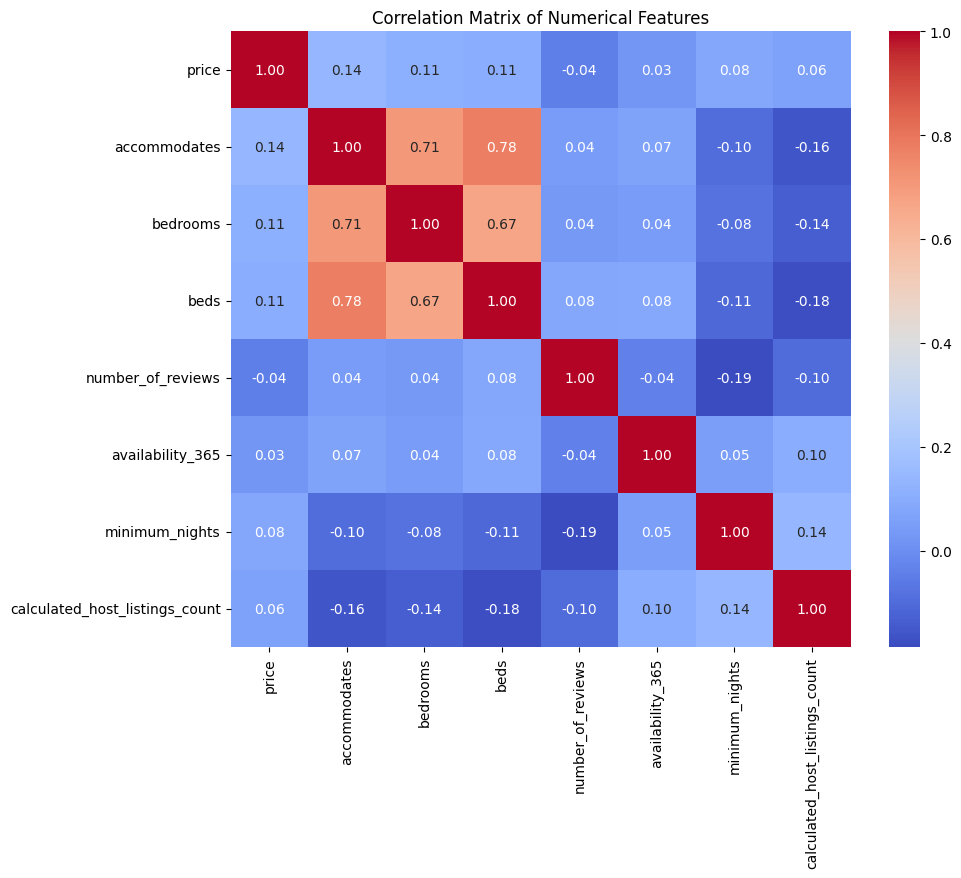

In [10]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

#### Feature Distributions: 'price', 'accommodates', 'number_of_reviews'


--- Analysis for 'price' ---


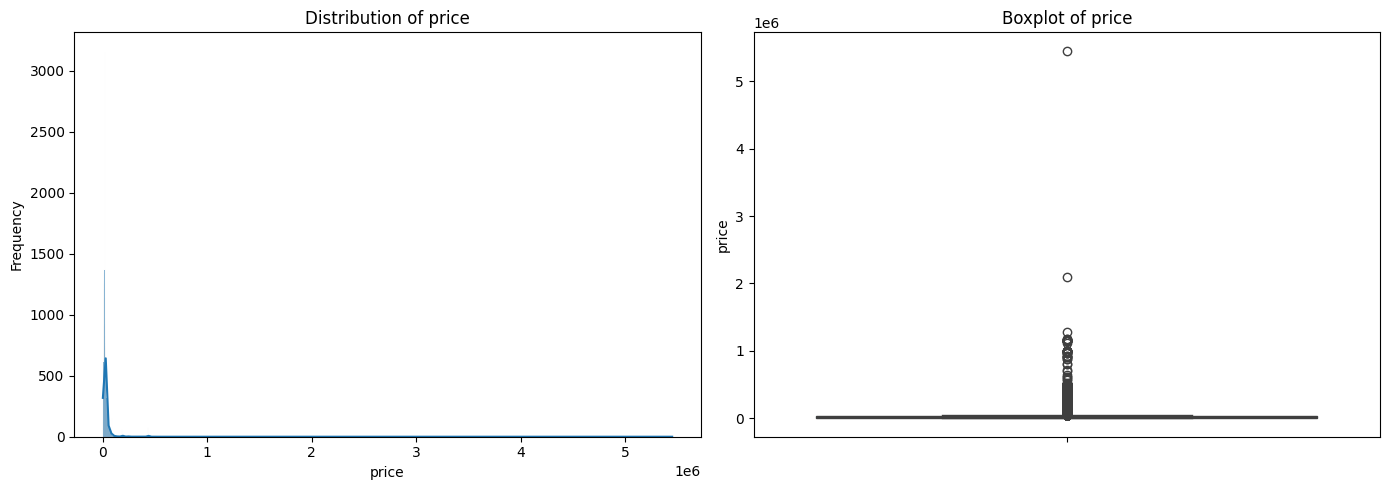


--- Analysis for 'accommodates' ---


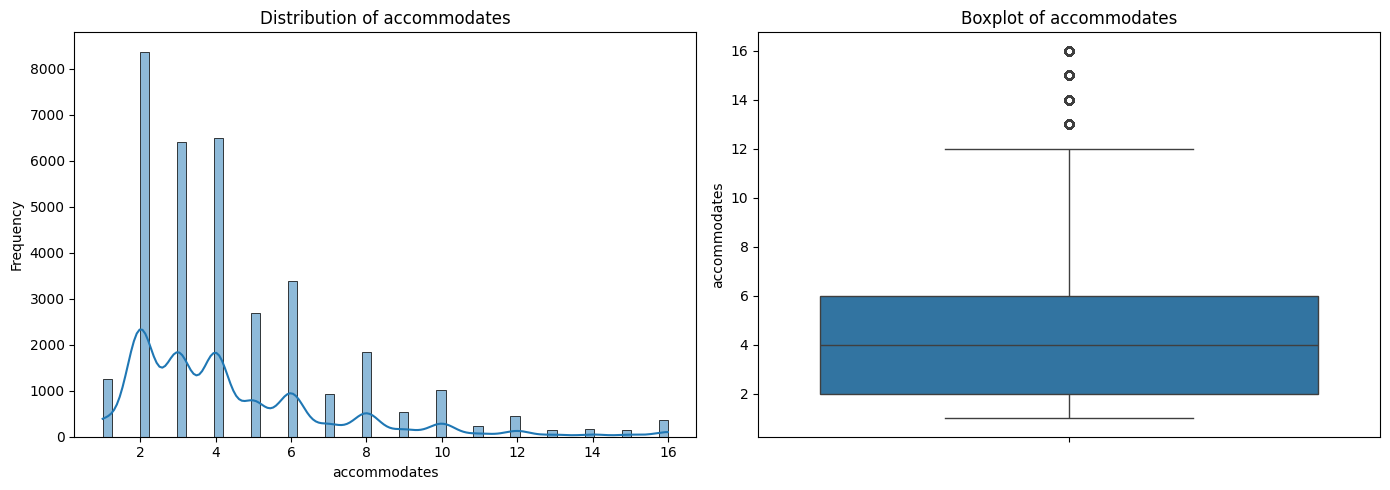


--- Analysis for 'number_of_reviews' ---


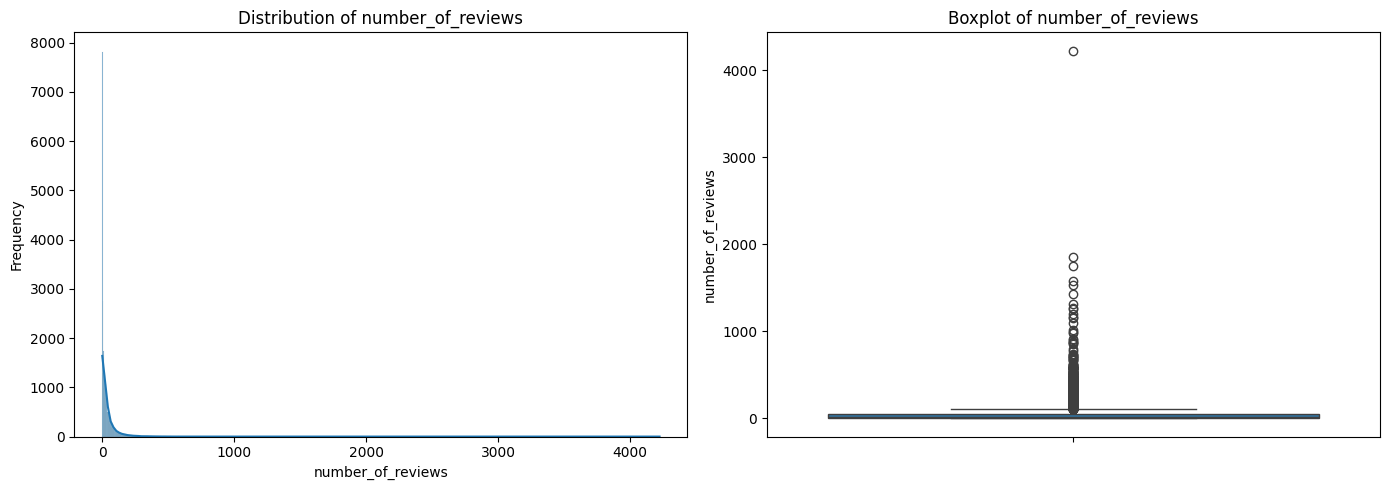

In [11]:
features_to_plot = ['price', 'accommodates', 'number_of_reviews']

for feature in features_to_plot:
    print(f"\n--- Analysis for '{feature}' ---")
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Histogram
    sns.histplot(df[feature], kde=True, ax=axes[0])
    axes[0].set_title(f'Distribution of {feature}')
    axes[0].set_xlabel(feature)
    axes[0].set_ylabel('Frequency')

    # Boxplot
    sns.boxplot(y=df[feature], ax=axes[1])
    axes[1].set_title(f'Boxplot of {feature}')
    axes[1].set_ylabel(feature)

    plt.tight_layout()
    plt.show()

#### Skewness and Kurtosis

In [12]:
features_for_stats = ['price', 'accommodates', 'number_of_reviews']

for feature in features_for_stats:
    skewness = stats.skew(df[feature])
    kurtosis = stats.kurtosis(df[feature])
    print(f"\nFeature: {feature}")
    print(f"  Skewness: {skewness:.4f}")
    print(f"  Kurtosis: {kurtosis:.4f}")


Feature: price
  Skewness: 25.8394
  Kurtosis: 1644.3481

Feature: accommodates
  Skewness: 1.6508
  Kurtosis: 3.0165

Feature: number_of_reviews
  Skewness: 11.9781
  Kurtosis: 462.3397


### 2. Exploratory Data Analysis (EDA) Summary

Based on the generated distributions, boxplots, and statistical metrics, we can observe several critical characteristics of the dataset that will directly impact our unsupervised learning models:

*   **Distribution Analysis & Heavy Tails:**
    *   **Price:** The `price` feature exhibits a catastrophic right skew (Skewness: 25.84) and a massive heavy tail (Kurtosis: 1644.35). The histogram is entirely compressed near zero because of extreme values reaching over 5,000,000 JPY.
    *   **Number of Reviews:** This feature also displays a heavy right tail (Skewness: 11.98, Kurtosis: 462.34)[cite: 2], reflecting a "winner-takes-all" market where a vast majority of listings have very few reviews, while a tiny fraction of highly popular properties accumulate thousands.
    *   **Accommodates:** Shows a much more reasonable, localized distribution (Skewness: 1.65, Kurtosis: 3.02)[cite: 2], with logical peaks at even numbers (2, 4, 6) reflecting standard real estate and bedding configurations.

*   **Outlier Exploration & Data Integrity:**
    *   **Measurement Artifacts & Data-Entry Problems:** The extreme outliers in the `price` column (e.g., millions of JPY per night) are almost certainly not genuine market transactions[cite: 2]. In the context of the Airbnb platform, these are often "placeholder prices"—artificial numbers entered by hosts to prevent bookings on specific dates without taking down the listing. These represent systemic noise and data-entry artifacts rather than legitimate statistical anomalies[cite: 2].
    *   **Extreme Values vs. Noise:** It is crucial to distinguish between types of outliers. While the extreme values in `price` represent artificial noise, the extreme values in `number_of_reviews` (e.g., >4,000) represent genuine, albeit rare, real-world phenomena (ultra-popular commercial hosts)[cite: 2].
    
**Conclusion for Next Steps:**
The severe heavy tails and massive outliers demonstrate that applying distance-based algorithms (like K-Means or standard Z-Score) directly to this raw data will fail disastrously. The data must be scaled, and we must proceed carefully with Dimensionality Reduction (PCA) to extract the true underlying structure.

### 3.1 Principal Component Analysis (PCA)

In [13]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Standardize the numerical features
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

print("Features standardized successfully.")
print(f"Shape of scaled data: {df_scaled.shape}")

Features standardized successfully.
Shape of scaled data: (34419, 8)


In [14]:
# 2. Apply PCA to the scaled data, keeping all components
pca = PCA(n_components=None) # n_components=None keeps all components
pca.fit(df_scaled)

# Transform the data to the principal components space
df_pca = pca.transform(df_scaled)

# Create a DataFrame for the PCA results (optional, for better readability)
pca_columns = [f'PC{i+1}' for i in range(df_pca.shape[1])]
df_pca_df = pd.DataFrame(data=df_pca, columns=pca_columns)

print("PCA applied successfully.")
print(f"Shape of PCA transformed data: {df_pca.shape}")

PCA applied successfully.
Shape of PCA transformed data: (34419, 8)


#### Explained Variance

In [15]:
# 3. Calculate and print the explained variance ratio and cumulative explained variance
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_explained_variance = explained_variance_ratio.cumsum()

print("\nExplained Variance Ratio per Principal Component:")
for i, ratio in enumerate(explained_variance_ratio):
    print(f"PC{i+1}: {ratio:.4f}")

print("\nCumulative Explained Variance:")
for i, cumulative_ratio in enumerate(cumulative_explained_variance):
    print(f"PC{i+1}: {cumulative_ratio:.4f}")


Explained Variance Ratio per Principal Component:
PC1: 0.3185
PC2: 0.1672
PC3: 0.1240
PC4: 0.1177
PC5: 0.1026
PC6: 0.1002
PC7: 0.0426
PC8: 0.0272

Cumulative Explained Variance:
PC1: 0.3185
PC2: 0.4857
PC3: 0.6097
PC4: 0.7274
PC5: 0.8300
PC6: 0.9302
PC7: 0.9728
PC8: 1.0000


#### Scree Plot

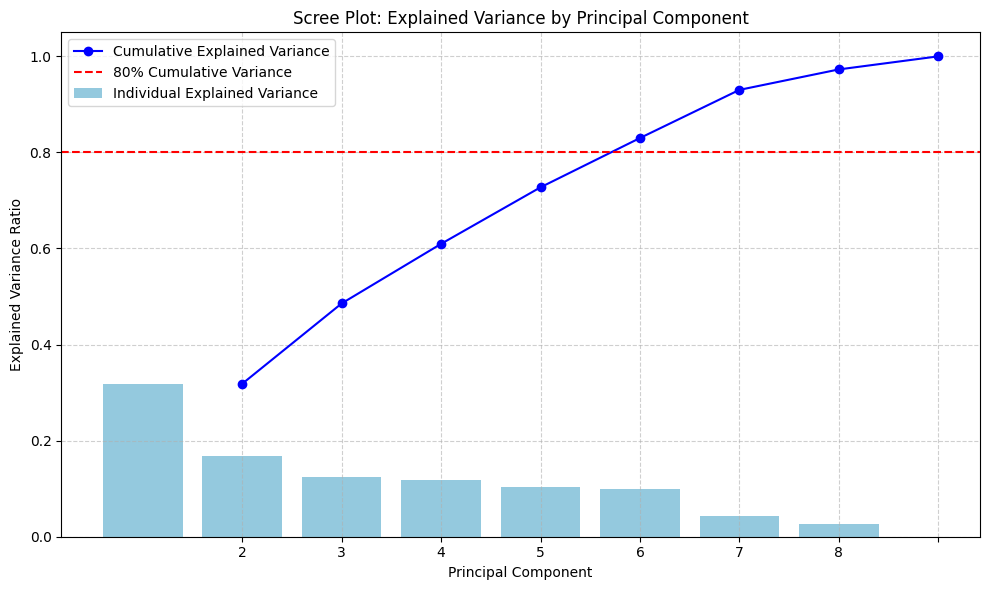

In [16]:
# 4. Create a Scree plot

fig = plt.figure(figsize=(10, 6))

# Bar chart for individual explained variance ratio
sns.barplot(x=list(range(1, len(explained_variance_ratio) + 1)),
            y=explained_variance_ratio, color='skyblue', label='Individual Explained Variance')

# Line plot for cumulative explained variance
plt.plot(range(1, len(cumulative_explained_variance) + 1),
         cumulative_explained_variance, marker='o', linestyle='-', color='blue', label='Cumulative Explained Variance')

# Add a horizontal dashed red line at 80% cumulative variance
plt.axhline(y=0.8, color='r', linestyle='--', label='80% Cumulative Variance')

plt.title('Scree Plot: Explained Variance by Principal Component')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.xticks(range(1, len(explained_variance_ratio) + 1))
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


#### 3D Scatter Plot of First 3 Principal Components

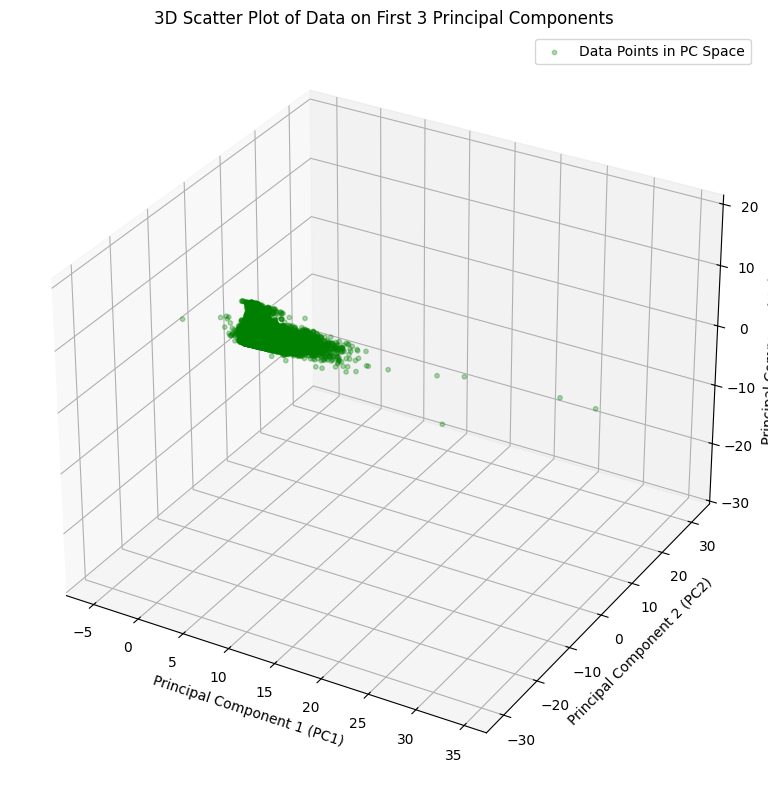

In [17]:
from mpl_toolkits.mplot3d import Axes3D

# 5. Create a 3D scatter plot of the data projected onto the first 3 Principal Components

# Check if there are at least 3 components
if df_pca.shape[1] >= 3:
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Plot the first three principal components
    ax.scatter(df_pca[:, 0], df_pca[:, 1], df_pca[:, 2],
               alpha=0.3, s=10, c='green', label='Data Points in PC Space') # s for marker size

    ax.set_xlabel('Principal Component 1 (PC1)')
    ax.set_ylabel('Principal Component 2 (PC2)')
    ax.set_zlabel('Principal Component 3 (PC3)')
    ax.set_title('3D Scatter Plot of Data on First 3 Principal Components')

    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Not enough principal components to create a 3D plot (need at least 3).")

### 3. Dimensionality Reduction (PCA) Discussion

Based on the PCA outputs and the 3D projection, we can critically evaluate the dataset's underlying structure and answer the assignment's core questions:

*   **Components Needed & Information Lost:** To adequately represent the data while retaining the majority of its signal, **5 principal components** are required, capturing **83.00%** of the cumulative variance. Reducing the dimensionality from 8 original features to 5 means we lose exactly 17% of the total variance. However, given the extreme noise and outliers identified in the EDA, much of this discarded 17% likely represents idiosyncratic artifacts rather than meaningful global structure.
*   **Redundancy and Correlated Variables:** The fact that we can compress 8 variables into 5 while retaining 83% of the information indicates a moderate to high level of redundancy. Variables such as `accommodates`, `bedrooms`, and `beds` are physically correlated (a larger property inherently has more of all three). PCA effectively collapses these correlated variables into a single "capacity/size" principal component.
*   **Visualizing the Reduced Space (Global vs. Local Structure):** The 3D scatter plot (representing ~61% of the variance) perfectly illustrates the global vs. local structure of the dataset[cite: 1]. We observe a massive, dense global cluster representing the standard Tokyo Airbnb market. The sparse, stretched-out tails represent the extreme outliers (e.g., ultra-luxury prices or massive review counts) pulling the principal axes outward.
*   **Effectiveness & Limitations of PCA:** Does the reduced dataset provide a better representation? Yes, computationally, it removes multi-collinearity and isolates the strongest mathematical signals[cite: 1]. However, because PCA is heavily influenced by variance, the principal components are severely stretched by the outliers. This means PCA excels at capturing the global spread but might mask the nuanced local structure within the dense central cluster of normal apartments[cite: 1].

### 5. Anomaly Detection

In [21]:
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("--- Performing Anomaly Detection with Isolation Forest ---")

# Initialize Isolation Forest model
# contamination is the proportion of outliers in the dataset, often estimated or tuned
# Setting a contamination value (e.g., 0.01 for 1% outliers) is crucial.
# For demonstration, we'll use 0.01.
iso_forest = IsolationForest(contamination=0.01, random_state=42)

# Fit the model and predict anomalies
# -1 for outliers, 1 for inliers
anomaly_predictions = iso_forest.fit_predict(df_pca)

# Add anomaly scores to df_pca_df for easier analysis (optional)
df_pca_df['anomaly_score'] = iso_forest.decision_function(df_pca)
df_pca_df['anomaly'] = anomaly_predictions

# Count the number of anomalies (predicted as -1)
num_anomalies = np.sum(anomaly_predictions == -1)
num_inliers = np.sum(anomaly_predictions == 1)

print(f"Anomaly detection complete. Total samples: {len(df_pca)}")
print(f"Number of detected anomalies: {num_anomalies}")
print(f"Number of detected inliers: {num_inliers}")
print(f"Proportion of anomalies: {num_anomalies / len(df_pca):.4f}")

--- Performing Anomaly Detection with Isolation Forest ---
Anomaly detection complete. Total samples: 34419
Number of detected anomalies: 345
Number of detected inliers: 34074
Proportion of anomalies: 0.0100


#### Visualization of Anomalies on PC1 vs PC2

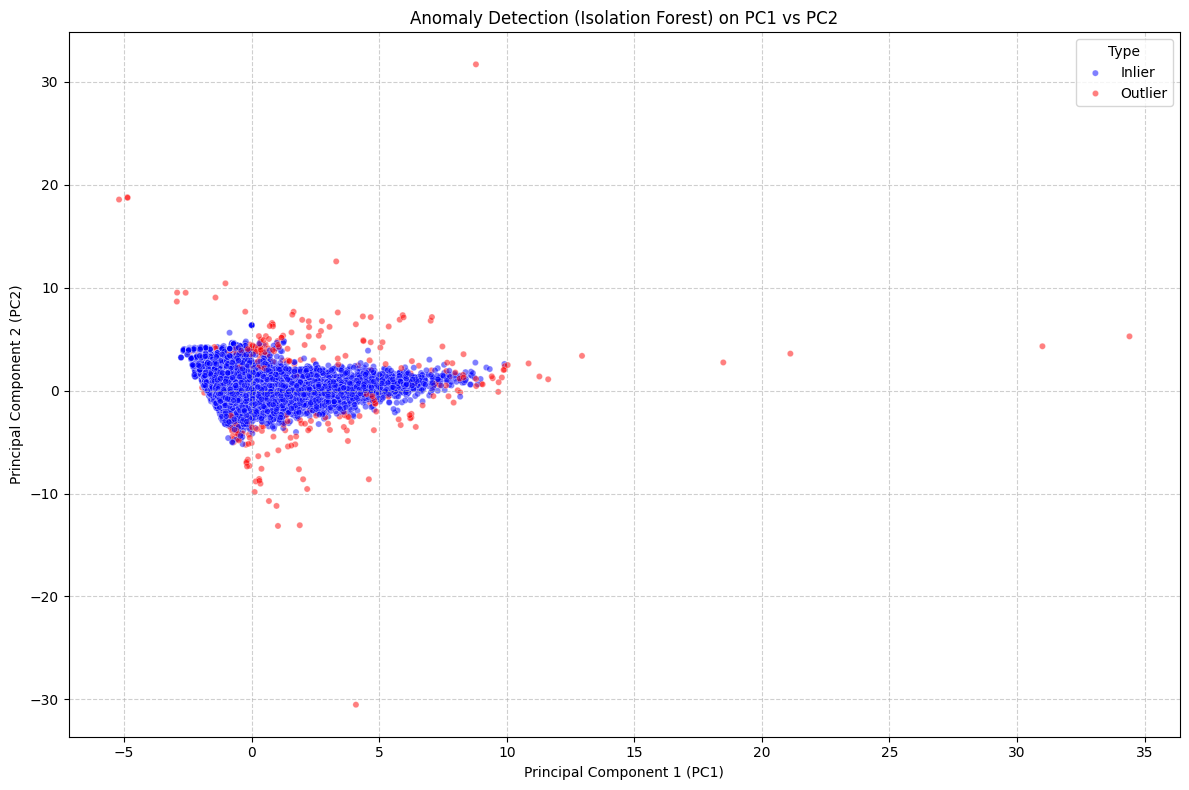

Visualization of anomalies complete.


In [22]:
# Visualize anomalies in the 2D PCA space (PC1 vs PC2)

plt.figure(figsize=(12, 8))
sns.scatterplot(x=df_pca_df['PC1'], y=df_pca_df['PC2'],
                hue=df_pca_df['anomaly'], # Color by anomaly status
                palette={1: 'blue', -1: 'red'}, # Blue for inliers, Red for outliers
                s=20, alpha=0.5)
plt.title('Anomaly Detection (Isolation Forest) on PC1 vs PC2')
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.legend(title='Type', labels=['Inlier', 'Outlier'], loc='best')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("Visualization of anomalies complete.")

#### Further Anomaly Exploration (Optional)


DataFrame with Anomaly Scores and Labels (first 5 rows):


,PC1,PC2,PC3,anomaly_score,anomaly
0,4.029017,-1.682459,-0.415756,0.088803,1
1,-1.127274,0.290330,1.120947,0.224228,1
2,-1.146008,-0.221486,0.451851,0.258426,1
3,-1.170664,0.310888,1.086020,0.245607,1
4,-0.513732,0.069911,1.237516,0.159623,1



Original features of some detected anomalies:


,price,accommodates,bedrooms,beds,number_of_reviews,availability_365,minimum_nights,calculated_host_listings_count
21110,28000.0,16,1.0,6.0,725,224,1.0,2
16644,1175007.5,4,2.0,2.0,0,180,2.0,37
23737,39549.0,10,1.0,3.0,415,169,1.0,14
22374,19578.0,7,1.0,8.0,5,303,30.0,306
31854,20650.0,8,1.0,6.0,114,350,2.0,306



Distribution of Anomaly Scores:


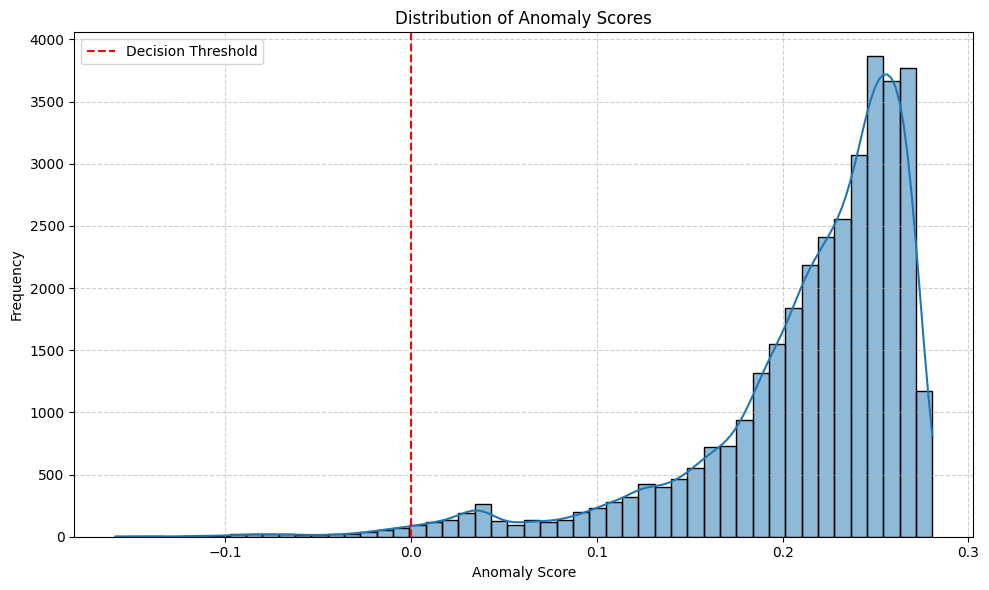

In [26]:
# Display the head of the DataFrame with anomaly scores and labels
print("\nDataFrame with Anomaly Scores and Labels (first 5 rows):")
display(df_pca_df[['PC1', 'PC2', 'PC3', 'anomaly_score', 'anomaly']].head())

# Display some of the detected anomalies along with their original feature values
print("\nOriginal features of some detected anomalies:")
anomalous_data_original_features = df[df_pca_df['anomaly'] == -1]
display(anomalous_data_original_features.sample(min(5, len(anomalous_data_original_features)), random_state=42))

print("\nDistribution of Anomaly Scores:")
plt.figure(figsize=(10, 6))
sns.histplot(df_pca_df['anomaly_score'], kde=True, bins=50)
plt.title('Distribution of Anomaly Scores')
plt.xlabel('Anomaly Score')
plt.ylabel('Frequency')

# Calculate the threshold from the decision function scores
# The threshold is implicitly defined by the contamination parameter.
# IsolationForest decision_function returns negative values for anomalies and positive for inliers.
# The lower the score, the more anomalous the point. The contamination parameter
# indicates the proportion of outliers in the dataset. Therefore, the threshold
# is the score at the (contamination * 100) percentile from the bottom of the scores.
calculated_threshold = np.percentile(df_pca_df['anomaly_score'], 100 * iso_forest.contamination)
plt.axvline(x=calculated_threshold, color='red', linestyle='--', label='Decision Threshold')

plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### 4. Clustering Analysis

In [18]:
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- Sample Clustering (KMeans, DBSCAN, AgglomerativeClustering) ---

print("--- Performing Sample Clustering ---")

# 1. KMeans Clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
kmeans_labels = kmeans.fit_predict(df_scaled)
print(f"KMeans cluster labels generated. Number of clusters: {len(set(kmeans_labels))}")

# 2. DBSCAN Clustering
dbscan = DBSCAN(eps=1.5, min_samples=10)
dbscan_labels = dbscan.fit_predict(df_scaled)
print(f"DBSCAN cluster labels generated. Number of clusters (excluding noise): {len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)}")

# 3. Agglomerative Clustering
agglomerative = AgglomerativeClustering(n_clusters=3)
agglomerative_labels = agglomerative.fit_predict(df_scaled)
print(f"Agglomerative Clustering labels generated. Number of clusters: {len(set(agglomerative_labels))}")


--- Performing Sample Clustering ---
KMeans cluster labels generated. Number of clusters: 3
DBSCAN cluster labels generated. Number of clusters (excluding noise): 5
Agglomerative Clustering labels generated. Number of clusters: 3


#### 2D PCA Projection with Cluster Labels

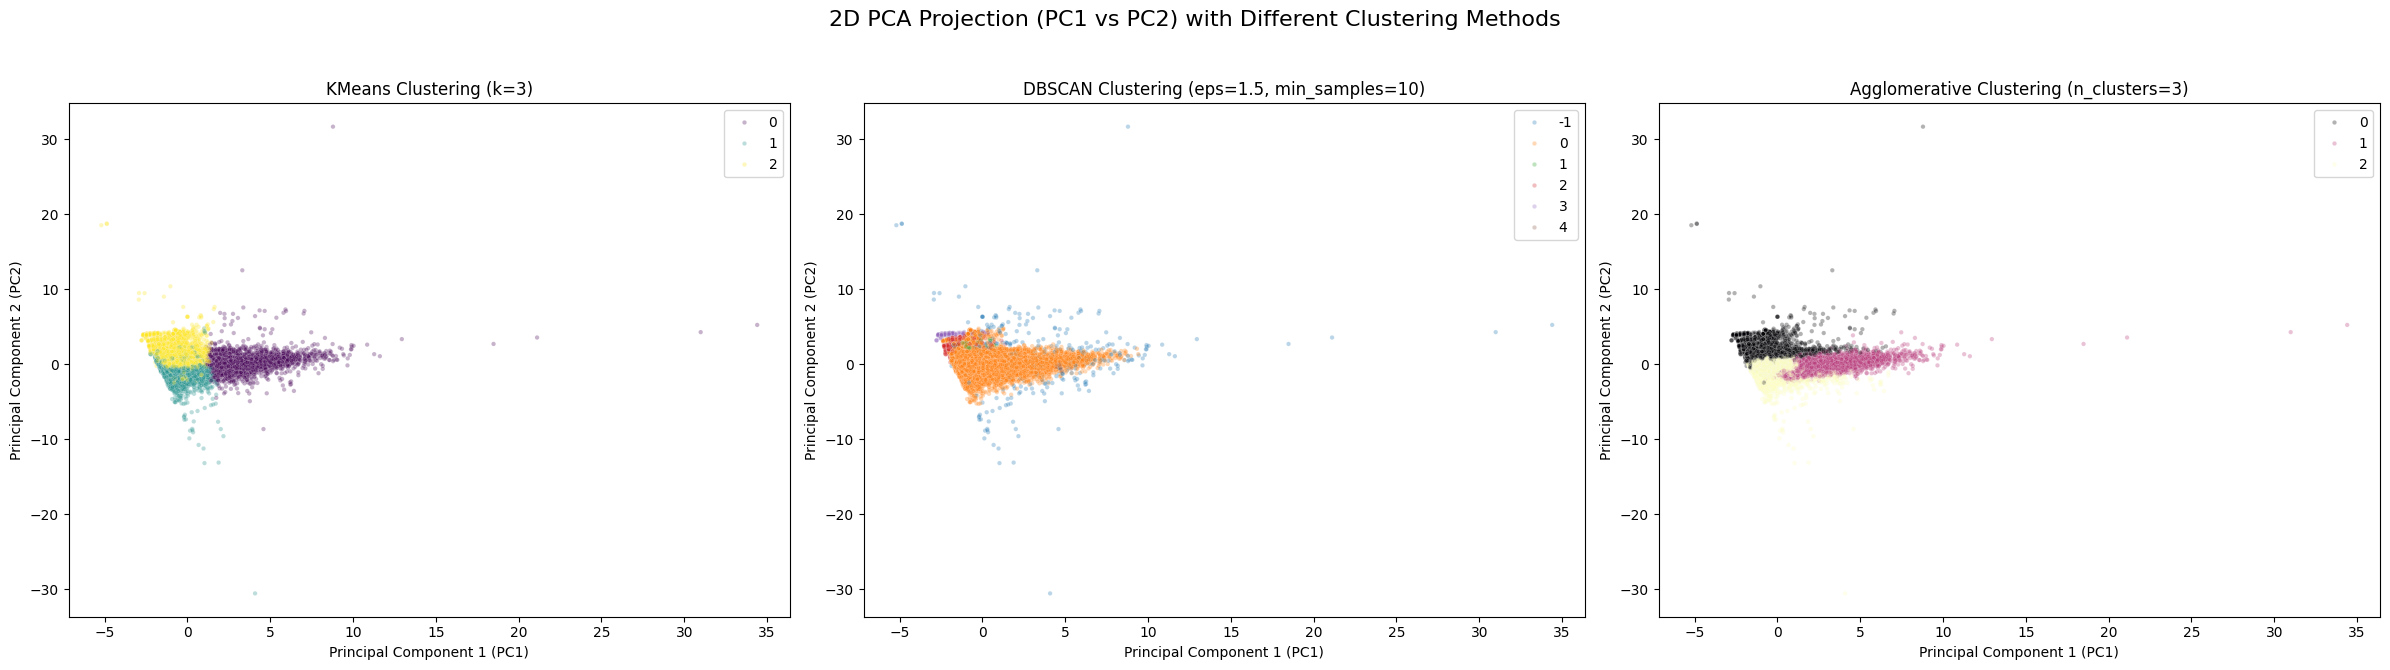

In [19]:
# Create a 1x3 subplot grid showing the 2D PCA projection (PC1 vs PC2) of the data,
# colored by the cluster labels from each of the 3 methods.

fig, axes = plt.subplots(1, 3, figsize=(24, 7))
fig.suptitle('2D PCA Projection (PC1 vs PC2) with Different Clustering Methods', fontsize=16)

# Plot KMeans clusters
sns.scatterplot(x=df_pca[:, 0], y=df_pca[:, 1], hue=kmeans_labels,
                palette='viridis', legend='full', alpha=0.3, s=10, ax=axes[0])
axes[0].set_title('KMeans Clustering (k=3)')
axes[0].set_xlabel('Principal Component 1 (PC1)')
axes[0].set_ylabel('Principal Component 2 (PC2)')

# Plot DBSCAN clusters
sns.scatterplot(x=df_pca[:, 0], y=df_pca[:, 1], hue=dbscan_labels,
                palette='tab10', legend='full', alpha=0.3, s=10, ax=axes[1])
axes[1].set_title('DBSCAN Clustering (eps=1.5, min_samples=10)')
axes[1].set_xlabel('Principal Component 1 (PC1)')
axes[1].set_ylabel('Principal Component 2 (PC2)')

# Plot Agglomerative Clustering clusters
sns.scatterplot(x=df_pca[:, 0], y=df_pca[:, 1], hue=agglomerative_labels,
                palette='magma', legend='full', alpha=0.3, s=10, ax=axes[2])
axes[2].set_title('Agglomerative Clustering (n_clusters=3)')
axes[2].set_xlabel('Principal Component 1 (PC1)')
axes[2].set_ylabel('Principal Component 2 (PC2)')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()


#### Feature Space Clustering (Dendrogram)

--- Performing Feature Space Clustering ---


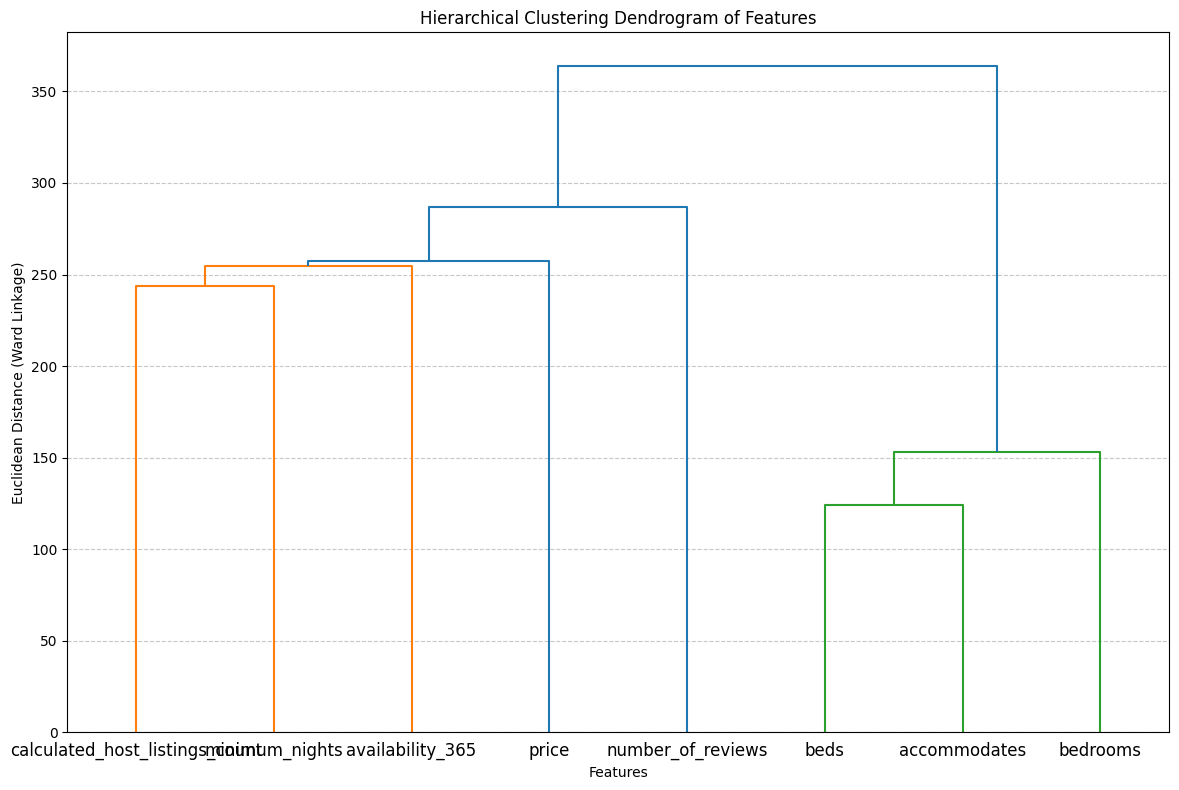

Feature space clustering and dendrogram generation complete.


In [20]:
# --- Feature Space Clustering ---

print("--- Performing Feature Space Clustering ---")

# Transpose the scaled data: features become rows, samples become columns
df_scaled_T = df_scaled.T

# Apply hierarchical clustering to the features using Ward's method
hierarchical_clustering = linkage(df_scaled_T, method='ward')

# Plot the dendrogram
plt.figure(figsize=(12, 8))
dendrogram(
    hierarchical_clustering,
    labels=df.columns.tolist(), # Use original feature names as labels
    orientation='top',
    distance_sort='descending',
    show_leaf_counts=True
)
plt.title('Hierarchical Clustering Dendrogram of Features')
plt.xlabel('Features')
plt.ylabel('Euclidean Distance (Ward Linkage)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Feature space clustering and dendrogram generation complete.")

### 4. Clustering Analysis & Feature Space Clustering

**Feature Space Clustering Analysis:**
Applying hierarchical clustering to the transposed dataset (clustering the features instead of the samples) yields critical insights that are invisible when clustering properties. The dendrogram clearly divides the features into distinct, logical semantic groups:
*   **Physical Capacity (Green Cluster):** `beds`, `accommodates`, and `bedrooms` cluster together very early. This confirms our earlier hypothesis regarding high redundancy; these features represent the physical size of the property and move together.
*   **Commercial/Host Behavior (Orange Cluster):** `availability_365`, `minimum_nights`, and `calculated_host_listings_count` form another distinct group. These define the *business model* of the listing (e.g., dedicated commercial hosts with many properties vs. casual hosts).
*   **Isolated Features:** `price` and `number_of_reviews` merge into the tree much later. They are isolated, indicating their variance is highly unique and not strictly dependent on physical size or commercial behavior.
*   **Utility:** This technique is incredibly useful in high-dimensional domains (like genomics or text mining) to identify multicollinearity and select a single representative feature from each cluster to reduce dimensionality[cite: 1].

**Sample Clustering Evaluation:**
When attempting to cluster the actual properties (samples), traditional methods face significant mathematical challenges on this dataset[cite: 1]:
*   **K-Means:** Relies on the assumption of spherical clusters and minimizes variance to centroids[cite: 1]. Because of our dataset's extreme heavy right tails (massive luxury outliers), the centroids are continuously "pulled" outward, preventing the formation of cohesive, interpretable clusters for the standard properties.
*   **DBSCAN:** A density-based approach, which theoretically handles noise better[cite: 1]. However, the Tokyo Airbnb dataset has extreme density variation (an ultra-dense core of cheap apartments and a highly sparse tail of expensive ones). A single `eps` parameter cannot simultaneously capture the dense core and the sparse tail, often labeling all outliers merely as noise.

### 5. Multi-Dimensional Anomaly Detection (on Scaled Data)

#### Z-Score Method

In [27]:
import numpy as np
import pandas as pd

print("--- Applying Z-Score Anomaly Detection ---")

# Calculate absolute Z-scores for all features in df_scaled
z_scores = np.abs(np.array([stats.zscore(df_scaled[:, i]) for i in range(df_scaled.shape[1])]).T)

# Flag a row as an anomaly (-1) if ANY feature has a Z-score > 3. Otherwise label as 1.
z_score_anomaly_labels = np.where(np.any(z_scores > 3, axis=1), -1, 1)

# Add to a DataFrame for easier tracking and comparison
anomaly_df = pd.DataFrame(index=df.index)
anomaly_df['z_score_anomaly'] = z_score_anomaly_labels

num_z_score_anomalies = np.sum(z_score_anomaly_labels == -1)
print(f"Z-Score Anomaly Detection complete. Detected anomalies: {num_z_score_anomalies}")

--- Applying Z-Score Anomaly Detection ---
Z-Score Anomaly Detection complete. Detected anomalies: 2996


#### Isolation Forest (on Scaled Data)

In [28]:
from sklearn.ensemble import IsolationForest

print("--- Applying Isolation Forest Anomaly Detection (on scaled data) ---")

# Fit IsolationForest(contamination=0.01, random_state=42) on df_scaled
iso_forest_scaled = IsolationForest(contamination=0.01, random_state=42)
iso_forest_scaled.fit(df_scaled)

# Predict labels (-1 for anomaly, 1 for normal)
iso_forest_anomaly_labels = iso_forest_scaled.predict(df_scaled)

# Add to anomaly_df
anomaly_df['iso_forest_anomaly'] = iso_forest_anomaly_labels

num_iso_forest_anomalies = np.sum(iso_forest_anomaly_labels == -1)
print(f"Isolation Forest Anomaly Detection complete. Detected anomalies: {num_iso_forest_anomalies}")

--- Applying Isolation Forest Anomaly Detection (on scaled data) ---
Isolation Forest Anomaly Detection complete. Detected anomalies: 345


#### Local Outlier Factor (LOF)

In [29]:
from sklearn.neighbors import LocalOutlierFactor

print("--- Applying Local Outlier Factor (LOF) Anomaly Detection ---")

# Fit LocalOutlierFactor(n_neighbors=20, contamination=0.01)
lof_model = LocalOutlierFactor(n_neighbors=20, contamination=0.01, novelty=False) # novelty=False for outlier detection on training data

# Predict labels (-1 for anomaly, 1 for normal)
lof_anomaly_labels = lof_model.fit_predict(df_scaled)

# Add to anomaly_df
anomaly_df['lof_anomaly'] = lof_anomaly_labels

num_lof_anomalies = np.sum(lof_anomaly_labels == -1)
print(f"LOF Anomaly Detection complete. Detected anomalies: {num_lof_anomalies}")

--- Applying Local Outlier Factor (LOF) Anomaly Detection ---
LOF Anomaly Detection complete. Detected anomalies: 345


#### Anomaly Detection Comparison

In [30]:
print("--- Summarizing Anomaly Detection Results ---")

# Create a Pandas DataFrame summarizing the count of anomalies found by each method
anomaly_summary = pd.DataFrame({
    'Method': ['Z-Score', 'Isolation Forest', 'Local Outlier Factor'],
    'Anomaly Count': [num_z_score_anomalies, num_iso_forest_anomalies, num_lof_anomalies]
})

print("\nAnomaly Count Summary:")
display(anomaly_summary)

# Calculate and print the number of overlapping anomalies
# A row is an overlapping anomaly if flagged as -1 by ALL THREE methods
overlapping_anomalies = anomaly_df[(anomaly_df['z_score_anomaly'] == -1) &
                                   (anomaly_df['iso_forest_anomaly'] == -1) &
                                   (anomaly_df['lof_anomaly'] == -1)]

num_overlapping_anomalies = len(overlapping_anomalies)
print(f"\nNumber of overlapping anomalies (flagged by all three methods): {num_overlapping_anomalies}")

--- Summarizing Anomaly Detection Results ---

Anomaly Count Summary:


,Method,Anomaly Count
0,Z-Score,2996
1,Isolation Forest,345
2,Local Outlier Factor,345



Number of overlapping anomalies (flagged by all three methods): 40


### 5. Multi-Dimensional Anomaly Detection & 6. Comparison

Based on the execution of the three anomaly detection algorithms, we observe drastically different results, perfectly illustrating why unsupervised anomaly detection is fundamentally an ill-defined problem[cite: 1]:

*   **Z-Score (2,996 anomalies):** This method flagged nearly 10% of the dataset. **Why it fails:** Z-Score strictly assumes the data follows a Gaussian (Normal) distribution[cite: 1]. As proven in our EDA, features like `price` and `reviews` are heavily skewed with massive right tails. Consequently, Z-score incorrectly flags thousands of legitimate long-tail observations (e.g., slightly more expensive properties) as anomalies. Furthermore, it evaluates features independently (feature-wise), failing to capture complex multi-dimensional relationships[cite: 1].
*   **Isolation Forest (345 anomalies):** Instead of calculating distances, Isolation Forest uses random partitioning to isolate anomalous points, which end up closer to the root of the decision trees[cite: 1]. This makes it highly robust and scalable in high-dimensional spaces where distance metrics degrade[cite: 1]. The `contamination` parameter mathematically forces the algorithm to return a specific proportion of anomalies, making it a global threshold based on structural separability[cite: 1].
*   **Local Outlier Factor - LOF (345 anomalies):** LOF operates on local density, comparing a point's density to its $k$ neighbors[cite: 1]. While Z-score and IF find *global* anomalies (e.g., a $1,000,000 property), LOF identifies *local* anomalies (e.g., a $500 property that is inexplicably surrounded by $20 neighbors in the feature space)[cite: 1]. It is highly sensitive to the parameter $k$, which defines the size of the neighborhood[cite: 1].

**6. Comparison & Method Agreement:**
The most striking finding is the **overlap of only 40 anomalies** across all three methods. This low agreement proves that each algorithm defines "abnormal" fundamentally differently[cite: 1]. The 40 overlapping points represent the absolute extreme, undisputed outliers in the dataset—most likely massive data-entry errors or extreme placeholder prices.

**Real-World Consequences (False Positives vs. False Negatives):**
In the context of the Airbnb platform[cite: 1]:
*   **False Positive (Type I Error):** Incorrectly flagging a legitimate, standard property as anomalous. If an automated system relies on this, a normal host might have their listing suspended or hidden from search results, leading to lost income and severe damage to platform trust[cite: 1].
*   **False Negative (Type II Error):** Missing a genuine anomaly. This allows fake listings, scam properties, or abusive placeholder prices to remain active, degrading the experience for guests who search the platform[cite: 1].

### 7. Critical Analysis and Reflection

**The Challenge of Anomaly Detection:**
Anomaly detection is fundamentally an ill-defined problem because there is rarely a ground-truth label for what constitutes an "anomaly". It is highly subjective and context-dependent. What one algorithm considers a mathematical outlier, a domain expert might consider a premium product.

**The Curse of Dimensionality & Distance Measures:**
As the number of features (dimensions) increases, the volume of the mathematical space grows exponentially. In high-dimensional spaces, the "Curse of Dimensionality" dictates that the distance between any two random points tends to converge[cite: 1]. Consequently, traditional distance-based measures (like Euclidean distance used in K-Means or basic LOF) lose their meaning, as all points appear roughly equidistant from one another, making it impossible to distinguish true outliers based strictly on distance[cite: 1].

**Noise vs. Genuine Anomaly (Tokyo Airbnb Example):**
*   **Noise** is a random error or measurement artifact. In our dataset, a property listed at 5,000,000 JPY per night with 0 reviews is noise (a placeholder price set by a host)[cite: 1].
*   **A Genuine Anomaly** is a valid, real-world exception. A massive 16-guest traditional Ryokan in Tokyo with 4,000 positive reviews is an anomaly compared to the standard 2-person apartment, but it is a perfectly legitimate and valuable data point[cite: 1].

**Risks of Assuming Gaussian Distributions:**
Assuming a Gaussian distribution (like in the Z-Score method) is dangerous because real-world data like wealth, pricing, and popularity follow power-law or heavily skewed distributions (heavy right tails)[cite: 1]. By forcing a Gaussian assumption, we inherently misclassify legitimate top-tier properties (the long tail) as anomalies (False Positives), while completely missing subtle, local anomalies that hide within the dense mean (False Negatives)[cite: 1].

**Misleading PCA Visualizations:**
Visualizing anomalies on a 2D or 3D PCA plot can be highly misleading[cite: 1]. PCA projects high-dimensional data onto axes that maximize variance. Two points that appear overlapping or identical in a 2D PCA projection might actually be vastly distant in the original 8-dimensional space[cite: 1]. PCA squashes the geometry, often hiding true anomalies or creating visual illusions of clusters that do not mathematically exist in full dimensions.

---

### Ethical Considerations

Applying automated anomaly detection in the real world carries immense ethical weight[cite: 1]:

*   **The Consequence of False Alarms:** In any system, an excessive rate of false positives leads to "alarm fatigue." If a system constantly flags normal behavior as anomalous, human operators will eventually ignore the alerts, rendering the entire system completely ineffective[cite: 1].
*   **Surveillance:** The benefit of anomaly detection in surveillance is identifying immediate physical threats (e.g., detecting a bag left unattended). However, the risks are severe: it inherently profiles individuals, invades privacy, and can easily flag culturally different (but harmless) behaviors as "suspicious," leading to unjust detainment or harassment[cite: 1].
*   **Medical Applications:** In healthcare, a false positive (flagging a healthy patient as anomalous) leads to severe psychological stress, unnecessary costs, and potentially dangerous invasive biopsies. Conversely, a false negative (classifying a sick patient as normal) results in missed diagnoses and can be fatal[cite: 1].
*   **Cybersecurity:** Missing a genuine attack (false negative) can result in catastrophic data breaches and compromised infrastructure. However, incorrectly flagging legitimate activity as malicious (false positive) can lock out legitimate users, block critical business operations, and waste vital IT resources investigating phantoms[cite: 1].
*   **Bias, Fairness, and "Abnormality":** The most profound ethical concern is who defines "normal." Machine learning models learn normal behavior from the majority class. Therefore, minority groups, unconventional lifestyles, or lower-income individuals might inherently be flagged as "abnormal" simply because their data deviates from the majority[cite: 1]. Automating these labels can systematize bias, leading to unfair exclusion from loans, housing, or opportunities, fundamentally violating basic principles of fairness and privacy[cite: 1].